# Customer Segmentation Analysis using K-Means Clustering

## Project Overview

Customer segmentation is the process of dividing customers into groups based on their characteristics and purchasing behavior. This project uses K-Means Clustering to identify distinct customer segments using Annual Income and Spending Score.

The insights generated from this analysis can help businesses create targeted marketing strategies, improve customer retention, and maximize revenue.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## Dataset Description

The dataset contains customer information collected by a shopping mall.

### Features

- CustomerID: Unique customer identifier
- Gender: Male or Female
- Age: Customer age
- Annual Income (k$): Annual income in thousands of dollars
- Spending Score (1-100): Score assigned based on customer spending behavior

### Objective

To identify different customer segments based on income and spending patterns using K-Means Clustering.

## Data Loading

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [ ]:
df = pd.read_excel('Mall_Customers.csv.xlsx')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Missing Value Analysis

Missing values can affect the accuracy of machine learning models. Therefore, the dataset is checked for any null or missing values.

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Duplicate Record Analysis

Duplicate records can introduce bias into the analysis. The dataset is checked to ensure that no duplicate entries exist.

In [ ]:
df.duplicated().sum()

np.int64(0)

## Statistical Summary

A statistical overview helps understand the distribution, central tendency, and variability of the numerical features.

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand customer demographics and spending behavior through visualizations.

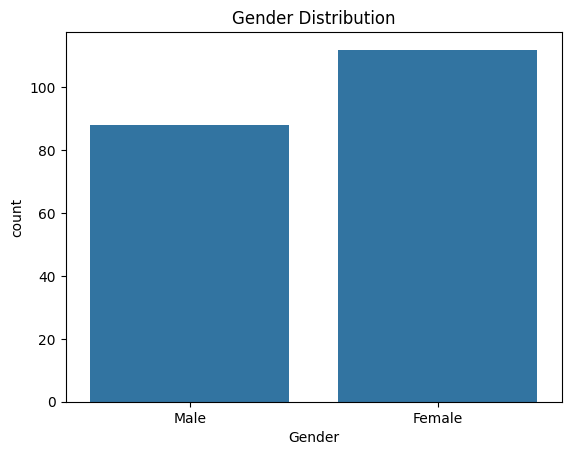

In [ ]:
sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')
plt.show()

### Observation

The dataset contains a balanced representation of male and female customers.

## Age Distribution

This visualization shows how customer ages are distributed across the dataset.

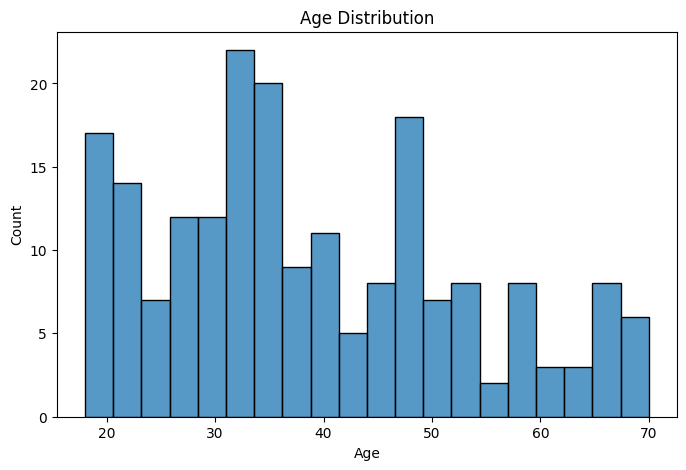

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title('Age Distribution')
plt.show()

### Observation

Most customers fall within the young and middle-aged groups, indicating a diverse customer base.

## Annual Income Distribution

This visualization helps understand the income levels of customers.

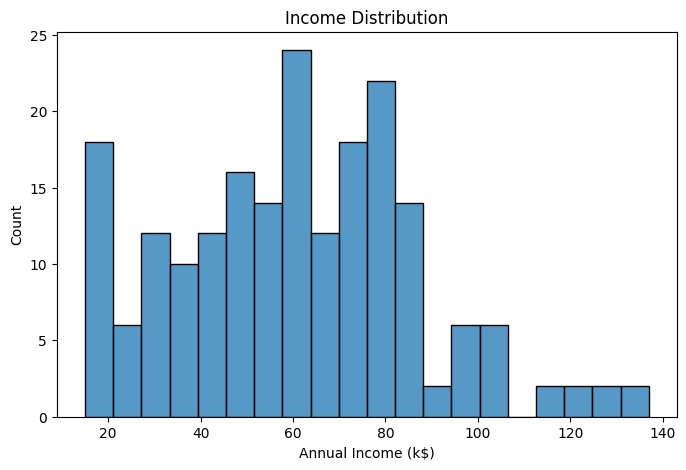

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20)

plt.title('Income Distribution')

plt.show()

### Observation

The majority of customers have annual incomes ranging between moderate and high levels.

## Spending Score Distribution

The spending score indicates how actively customers spend within the mall.

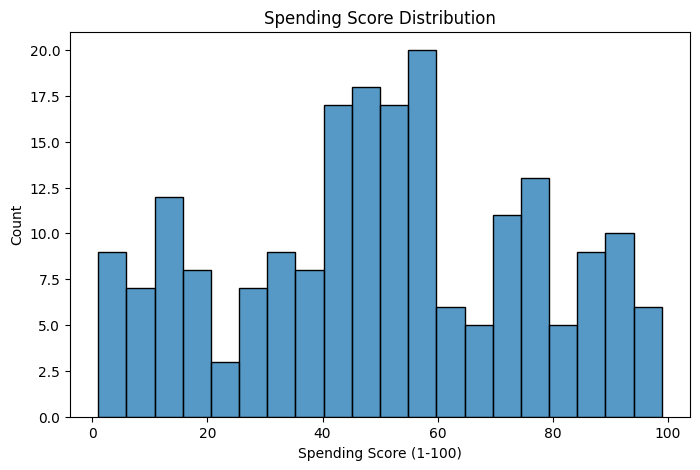

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20)

plt.title('Spending Score Distribution')

plt.show()

### Observation

Customer spending behavior varies significantly, making segmentation an appropriate analytical approach.

## Correlation Analysis

A correlation matrix is used to identify relationships between numerical variables in the dataset.

In [ ]:
numeric_df = df.select_dtypes(include='number')

numeric_df.corr()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


### Observation

The variables show limited linear correlation, suggesting that clustering techniques can uncover hidden patterns within the data.

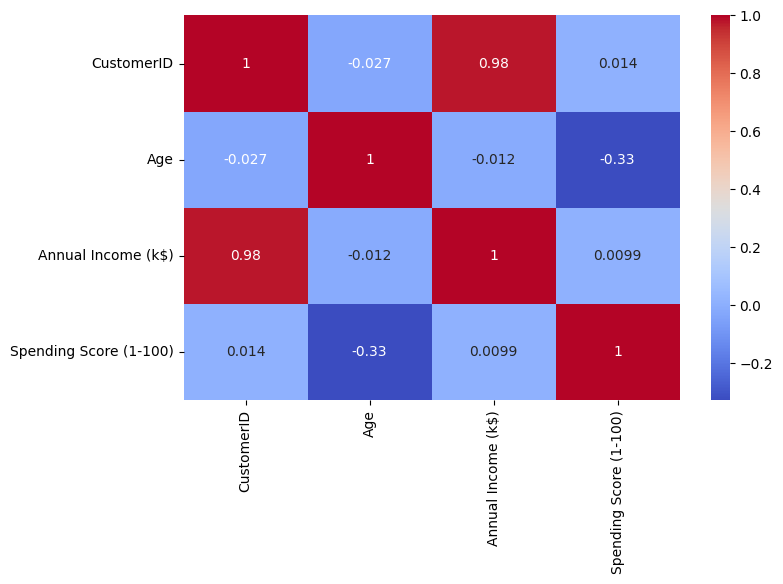

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Feature Selection

Annual Income and Spending Score are selected as the primary features because they best represent customer purchasing behavior and spending potential.

In [ ]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

## Feature Scaling

Feature scaling standardizes the data so that all variables contribute equally to the clustering process.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

## Determining Optimal Number of Clusters

The Elbow Method is used to determine the most suitable number of clusters for K-Means Clustering.

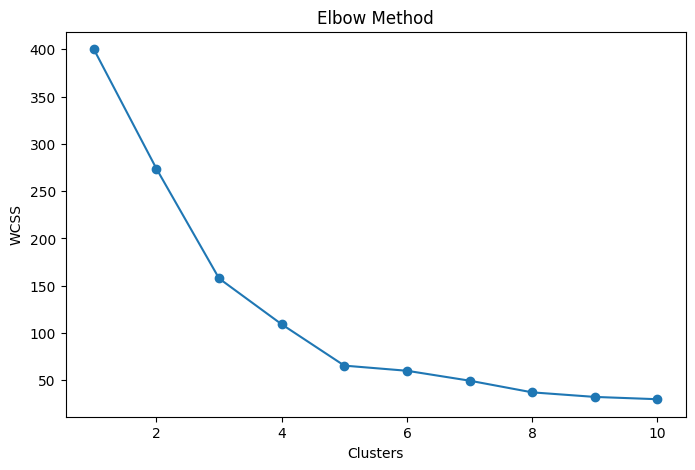

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')

plt.show()

### Observation

The elbow point appears at K = 5, indicating that five clusters provide an optimal balance between simplicity and accuracy.

## K-Means Clustering

K-Means Clustering is applied to divide customers into distinct groups based on their income and spending patterns.

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Customer Segmentation Visualization

The scatter plot illustrates the customer groups identified by the clustering algorithm.

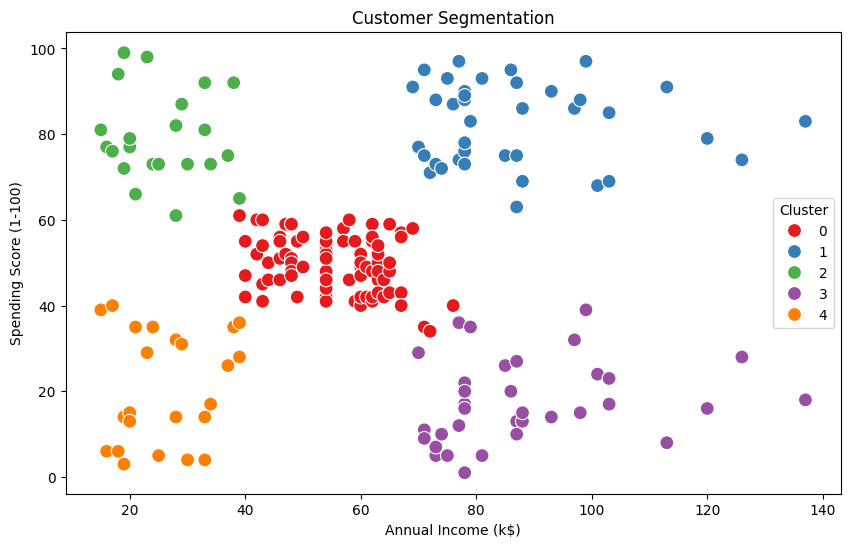

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title('Customer Segmentation')

plt.show()

### Observation

Five distinct customer segments can be observed, each exhibiting unique spending and income characteristics.

## Cluster Profiling

Cluster profiling helps understand the characteristics of each customer segment by analyzing average age, income, and spending score.

In [ ]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


# Customer Segment Profiles

### Cluster 0 – Average Customers
- Moderate income
- Moderate spending behavior
- Represents the general customer base

### Cluster 1 – Premium Customers
- High income
- High spending score
- Most valuable customer segment

### Cluster 2 – Impulsive Customers
- Low income
- High spending behavior
- Likely influenced by promotions

### Cluster 3 – Careful Customers
- High income
- Low spending score
- Potential target for personalized campaigns

### Cluster 4 – Budget Customers
- Low income
- Low spending behavior
- Highly price-sensitive customers

# Business Insights

1. Premium Customers generate the highest revenue potential and should be prioritized through loyalty programs and exclusive offers.

2. Careful Customers possess strong purchasing power but demonstrate low spending activity, making them ideal targets for personalized campaigns.

3. Impulsive Customers respond well to promotional offers and discount-driven marketing strategies.

4. Budget Customers are price-sensitive and should be targeted through affordable product offerings.

5. Average Customers represent the largest customer base and can be retained through cross-selling and engagement strategies.

# Conclusion

This project successfully applied K-Means Clustering to segment customers based on annual income and spending behavior.

Five distinct customer segments were identified:
- Premium Customers
- Careful Customers
- Impulsive Customers
- Budget Customers
- Average Customers

The analysis demonstrates how customer segmentation can support data-driven marketing decisions, improve customer engagement, and enhance business performance through targeted strategies.